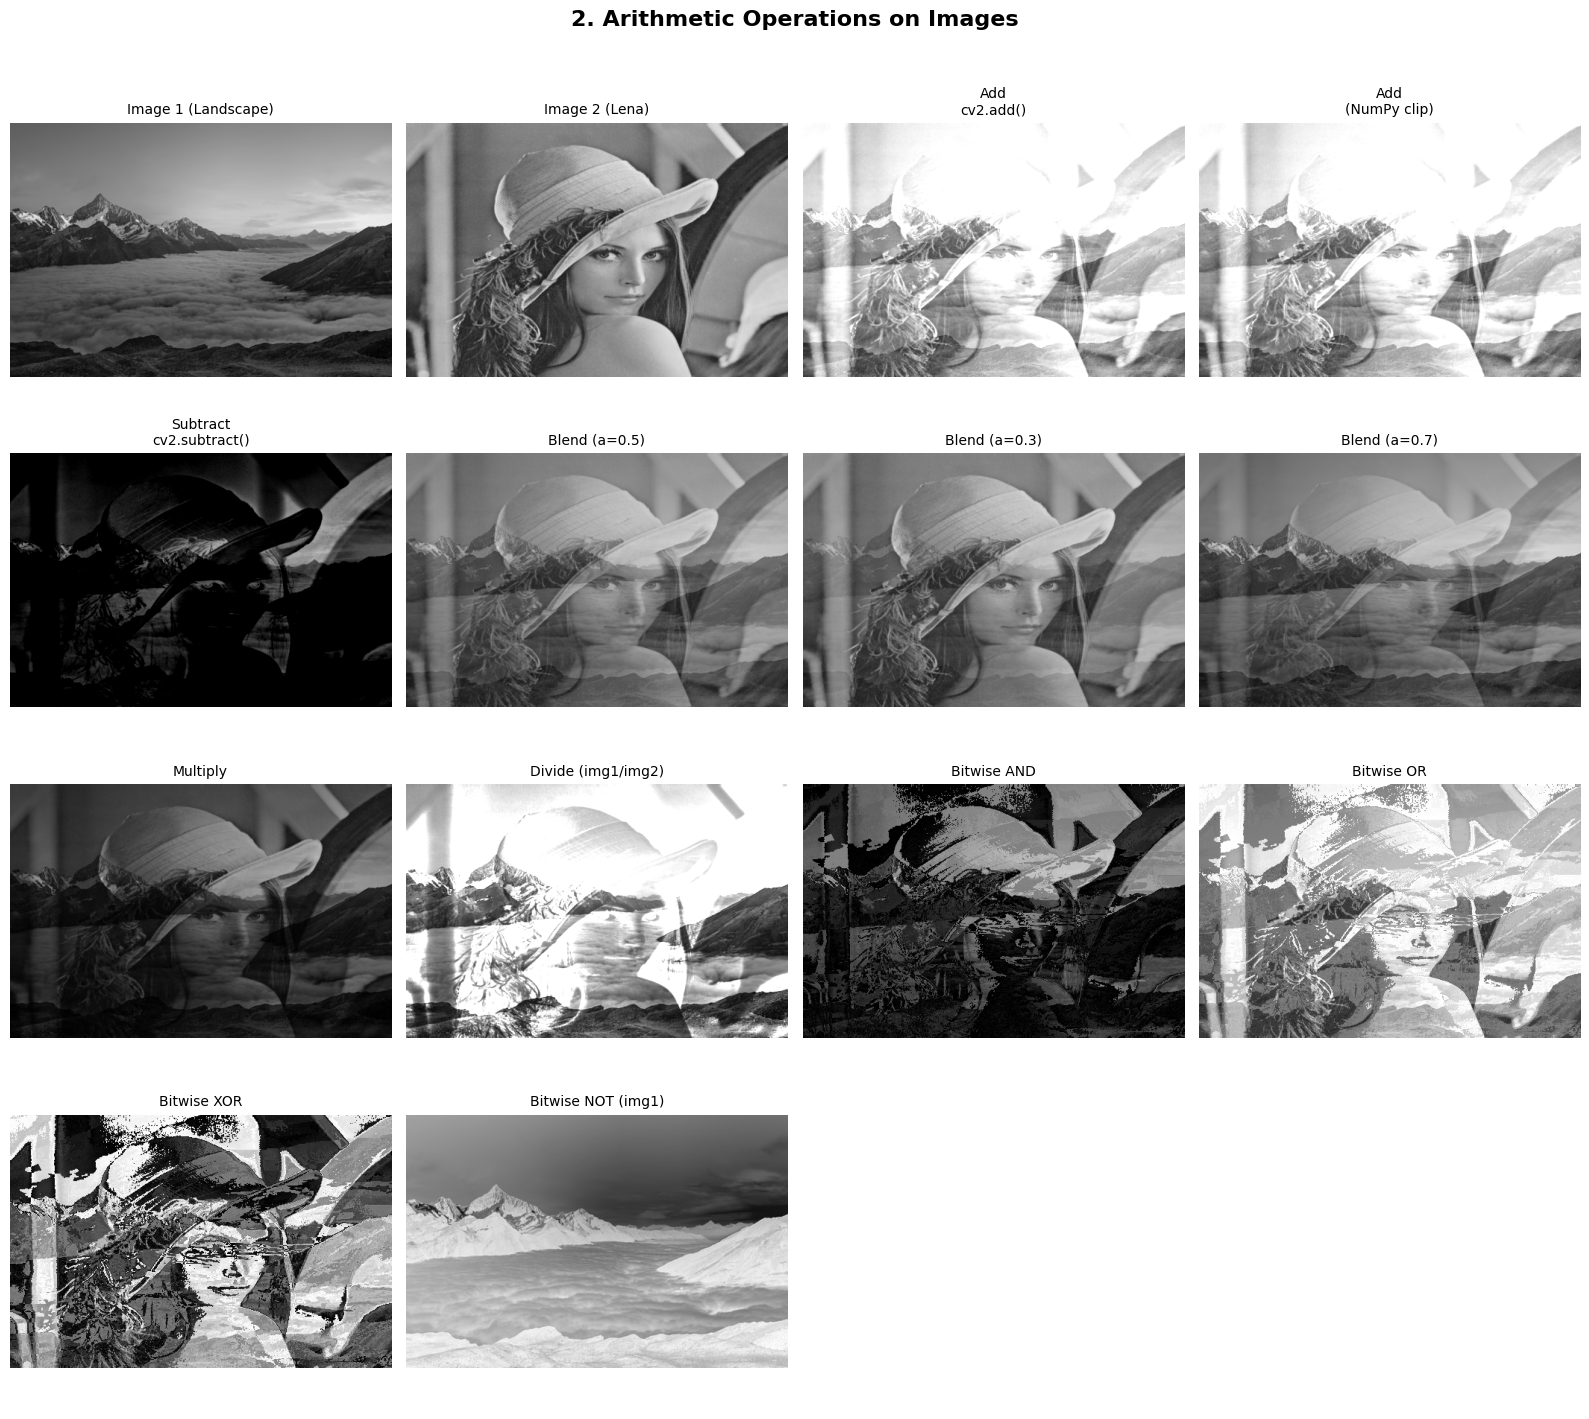

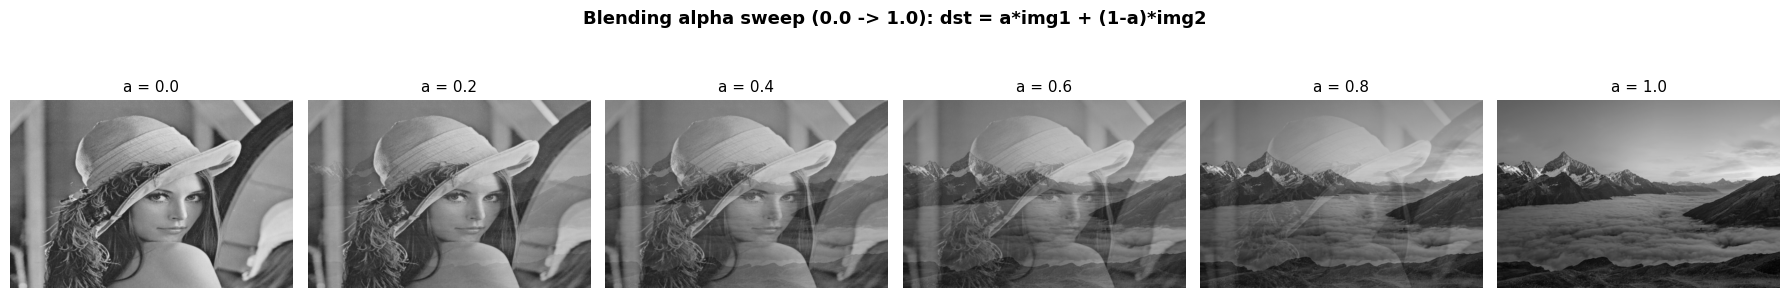

In [1]:
"""
이미지 산술 연산 (Arithmetic Operations on Images)
"""

import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request

# ──────────────────────────────────────────────
# 0. 이미지 다운로드 및 로드
# ──────────────────────────────────────────────

urllib.request.urlretrieve(
    "https://images.unsplash.com/photo-1506905925346-21bda4d32df4?w=512",
    "img1_landscape.jpg"
)
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg",
    "img2_lena.jpg"
)

img1 = cv2.imread("img1_landscape.jpg", cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread("img2_lena.jpg", cv2.IMREAD_GRAYSCALE)

# 두 이미지 크기 통일 (산술 연산은 크기가 같아야 함)
img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

# ──────────────────────────────────────────────
# 1. 산술 연산 함수 정의
# ──────────────────────────────────────────────

def op_add(a, b):
    return cv2.add(a, b)

def op_add_numpy(a, b):
    return (a.astype(np.int16) + b.astype(np.int16)).clip(0, 255).astype(np.uint8)

def op_subtract(a, b):
    return cv2.subtract(a, b)

def op_blend(a, b, alpha=0.5):
    return cv2.addWeighted(a, alpha, b, 1 - alpha, 0)

def op_multiply(a, b, scale=1/255):
    result = a.astype(np.float32) * b.astype(np.float32) * scale
    return result.clip(0, 255).astype(np.uint8)

def op_divide(a, b):
    with np.errstate(divide='ignore', invalid='ignore'):
        result = np.where(b != 0,
                          (a.astype(np.float32) / b.astype(np.float32) * 255),
                          0)
    return result.clip(0, 255).astype(np.uint8)

def op_bitwise_and(a, b):
    return cv2.bitwise_and(a, b)

def op_bitwise_or(a, b):
    return cv2.bitwise_or(a, b)

def op_bitwise_xor(a, b):
    return cv2.bitwise_xor(a, b)

def op_bitwise_not(a):
    return cv2.bitwise_not(a)

# ──────────────────────────────────────────────
# 2. 모든 연산 수행
# ──────────────────────────────────────────────

results = {
    "Image 1 (Landscape)":     img1,
    "Image 2 (Lena)":          img2,
    "Add\ncv2.add()":          op_add(img1, img2),
    "Add\n(NumPy clip)":       op_add_numpy(img1, img2),
    "Subtract\ncv2.subtract()":op_subtract(img1, img2),
    "Blend (a=0.5)":           op_blend(img1, img2, alpha=0.5),
    "Blend (a=0.3)":           op_blend(img1, img2, alpha=0.3),
    "Blend (a=0.7)":           op_blend(img1, img2, alpha=0.7),
    "Multiply":                op_multiply(img1, img2),
    "Divide (img1/img2)":      op_divide(img1, img2),
    "Bitwise AND":             op_bitwise_and(img1, img2),
    "Bitwise OR":              op_bitwise_or(img1, img2),
    "Bitwise XOR":             op_bitwise_xor(img1, img2),
    "Bitwise NOT (img1)":      op_bitwise_not(img1),
}

# ──────────────────────────────────────────────
# 3. 시각화
# ──────────────────────────────────────────────

n = len(results)
cols = 4
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3.5))
fig.suptitle("2. Arithmetic Operations on Images", fontsize=16, fontweight='bold', y=1.01)

axes_flat = axes.flatten()

for idx, (title, img) in enumerate(results.items()):
    ax = axes_flat[idx]
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, fontsize=10, pad=6)
    ax.axis('off')

for idx in range(n, len(axes_flat)):
    axes_flat[idx].axis('off')

plt.tight_layout()
plt.savefig("arithmetic_results.png", dpi=150, bbox_inches='tight')
plt.show()

# ──────────────────────────────────────────────
# 4. 블렌딩 alpha sweep 시각화
# ──────────────────────────────────────────────

alphas = np.linspace(0, 1, 6)
fig2, axes2 = plt.subplots(1, len(alphas), figsize=(18, 3.5))
fig2.suptitle("Blending alpha sweep (0.0 -> 1.0): dst = a*img1 + (1-a)*img2",
              fontsize=13, fontweight='bold')

for ax, a in zip(axes2, alphas):
    blended = op_blend(img1, img2, alpha=a)
    ax.imshow(blended, cmap='gray', vmin=0, vmax=255)
    ax.set_title(f"a = {a:.1f}", fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.savefig("blending_alpha_sweep.png", dpi=150, bbox_inches='tight')
plt.show()